## test new histograms locally

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep

In [2]:
vr = "28"
nfiles = -1
sig2mu = [
    "2Mu2E_500GeV_0p25GeV_4p0mm", #changing MZd
    "2Mu2E_500GeV_1p2GeV_19p0mm",
    "2Mu2E_500GeV_5p0GeV_80p0mm",
]

sig4mu = [
    "4Mu_500GeV_0p25GeV_0p004mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
]

channels = [
    "baseNoLj",
    "bkg_iso_disp",
    "bkg_iso_disp_2mu2e",
    "bkg_iso_disp_2mu2e_dphi",
]

ch1 = channels[0] # base
ch2 = channels[1] # iso + disp
ch3 = channels[2] # 2mu2e
ch4 = channels[3] # dphi

In [3]:
runner = processor.Runner(
    executor=processor.FuturesExecutor(),                # for testing locally
    # executor=processor.IterativeExecutor(),            # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
    unweighted_hist=True, verbose=False
)

In [4]:
# process 2mu2e
# fileset2mu = utilities.make_fileset(sig2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
# out2mu = runner.run(fileset2mu, treename="Events", processor_instance=p)
# out2mu = out2mu["out"]
# coffea.util.save(out2mu, "outputs/bkg_" + vr + "_2mu.coffea")

In [5]:
#process 4mu
# fileset4mu = utilities.make_fileset(sig4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
# out4mu = runner.run(fileset4mu, treename="Events", processor_instance=p)
# out4mu = out4mu["out"]
# coffea.util.save(out4mu, "outputs/bkg_" + vr + "_4mu.coffea")

In [6]:
out2 = coffea.util.load("outputs/bkg_28_2mu.coffea")
out4 = coffea.util.load("outputs/bkg_28_4mu.coffea")
output = {**out2, **out4}

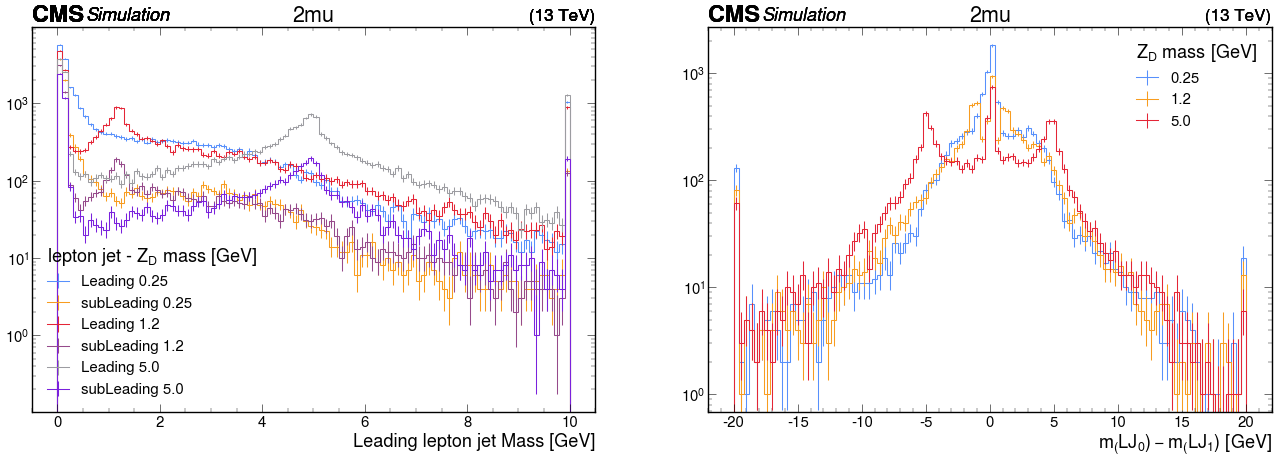

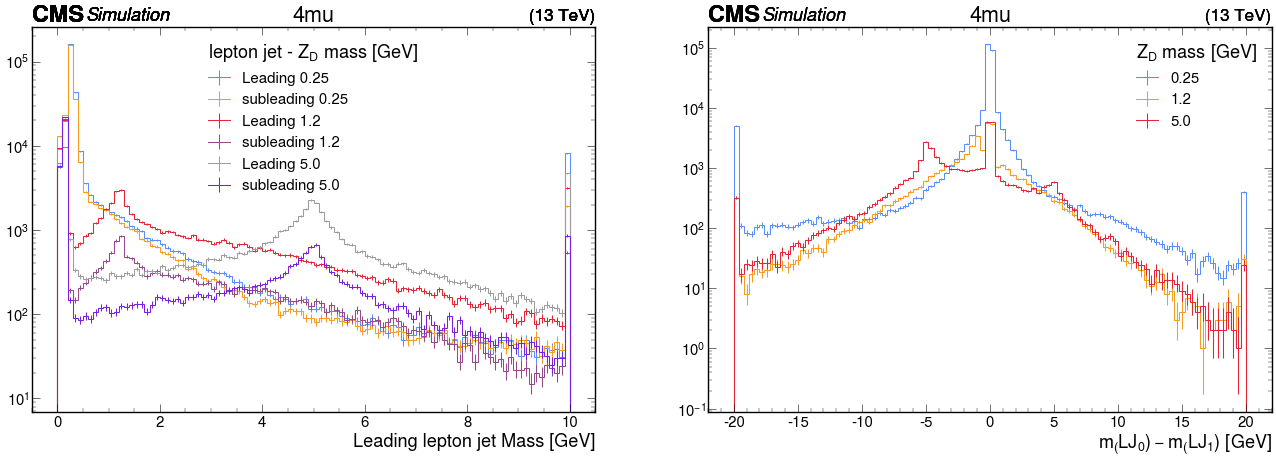

In [7]:
cha = ch2
npl = 2
mzd = ["0.25", "1.2", "5.0"]

###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss2]["hists"]["lj1_mass"][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)


###################
#### 4mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss4]["hists"]["lj1_mass"][cha, :], label = f"subleading {mzd[im]}")
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

Left plots contain the leading and subleading lj mass for three different dark photon simulated masses, 0.25, 1.2, 5.0 [GeV]. The top row is for the $2\mu$ case while the bottom plot is for $4\mu$. Right plots contain the difference (lj0-lj1) in mass for each of the three cases.
The peaks are in the right place but the difference in mass does not look too good. Specially for the 5 GeV case there are three peaks, at 0, $\pm 5$ meaning that both lepton lepton jet mass was reconstructed and have similar values, then one was reconstructed at the right place but the other one was not.


4Mu_500GeV_1p2GeV_19p0mm


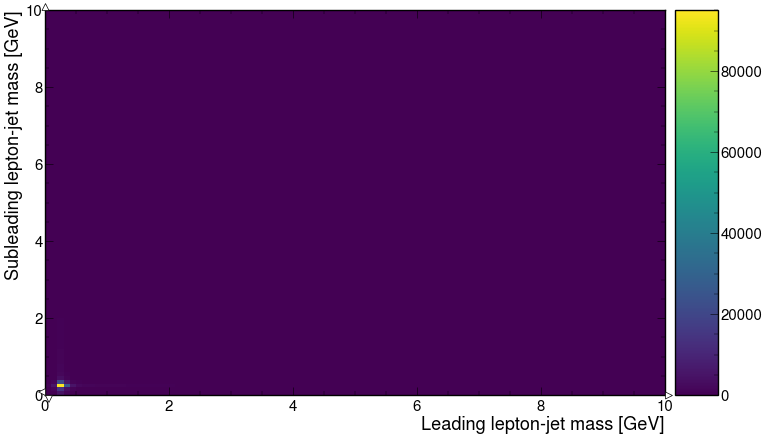

In [8]:
import matplotlib.pyplot as plt
import mplhep as hep
print(sig4mu[1])
h2 = output[sig4mu[0]]["hists"]["lj0_vs_lj1_mass"][ch1, :, :]

fig, ax = plt.subplots(figsize=(16, 10))

hep.hist2dplot(h2, ax=ax)

ax.set_xlabel("Leading lepton-jet mass [GeV]")
ax.set_ylabel("Subleading lepton-jet mass [GeV]")

plt.show()

/tmp/ipykernel_7036/901420131.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


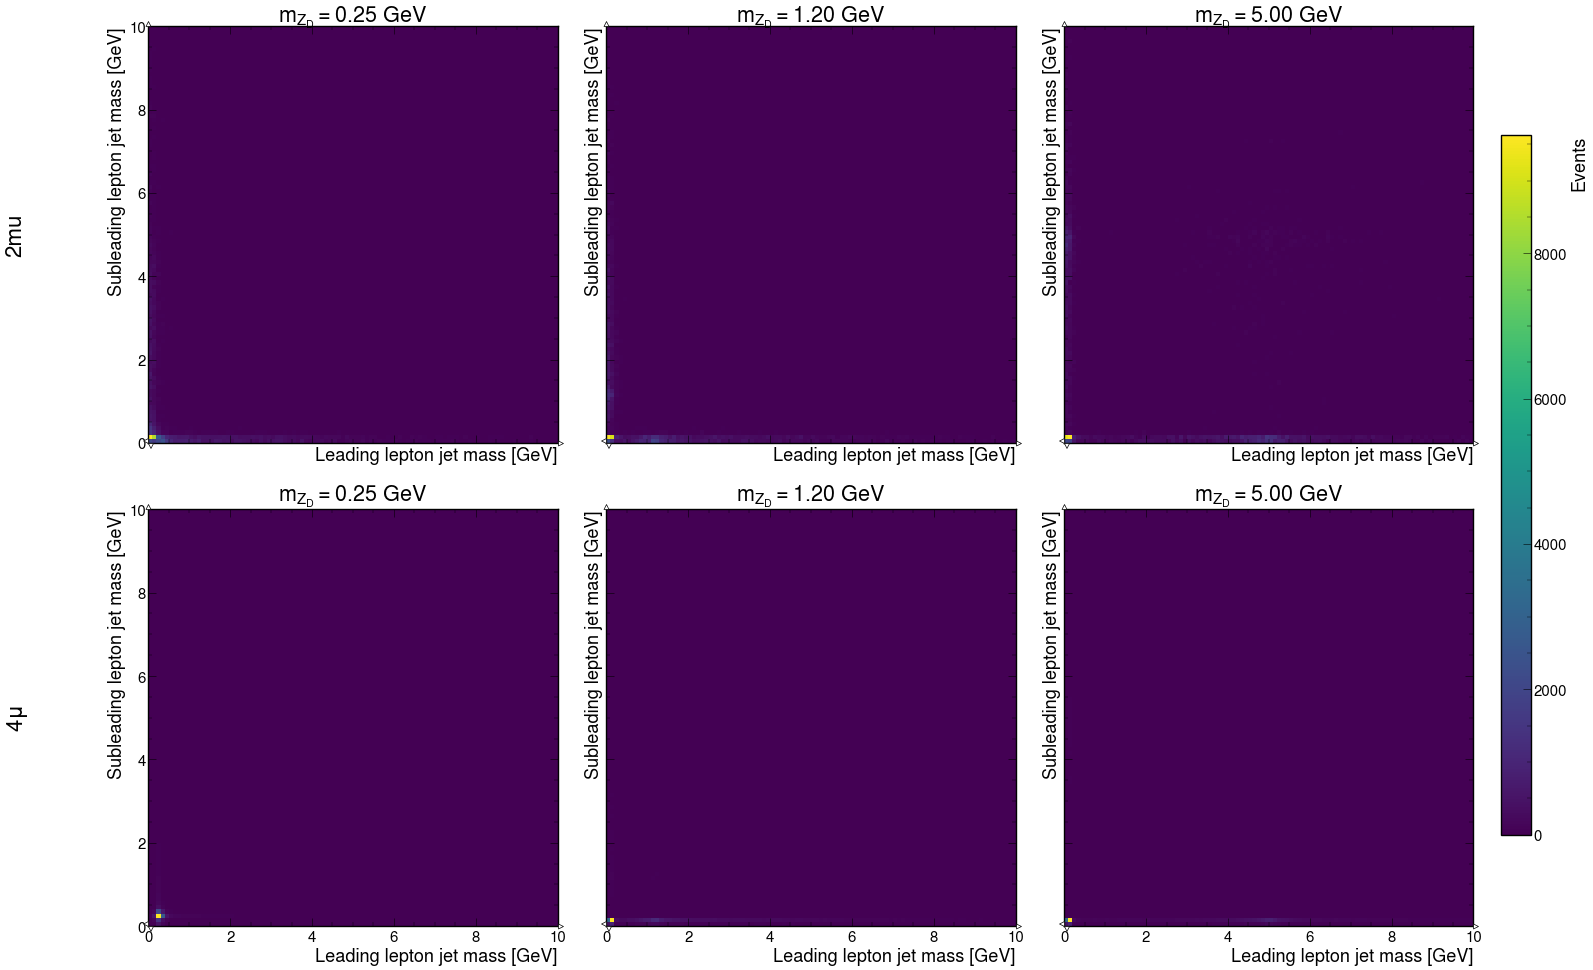

In [9]:
htp = "lj0_vs_lj1_mass"
ch = ch1
# Collect histograms
histograms = [
    (output[sig2mu[0]]["hists"][htp][ch, :, :], r"$m_{Z_D}=0.25$ GeV"),
    (output[sig2mu[1]]["hists"][htp][ch, :, :], r"$m_{Z_D}=1.20$ GeV"),
    (output[sig2mu[2]]["hists"][htp][ch, :, :], r"$m_{Z_D}=5.00$ GeV"),
    (output[sig4mu[0]]["hists"][htp][ch, :, :], r"$m_{Z_D}=0.25$ GeV"),
    (output[sig4mu[1]]["hists"][htp][ch, :, :], r"$m_{Z_D}=1.20$ GeV"),
    (output[sig4mu[2]]["hists"][htp][ch, :, :], r"$m_{Z_D}=5.00$ GeV"),
]

# Common color scale
vmax = max(h.values().max() for h, _ in histograms)

fig, axs = plt.subplots( 2, 3, figsize=(30, 20), sharex=True, sharey=True)

mappable = None

for ax, (h2, title) in zip(axs.flat, histograms):
    artists = hep.hist2dplot(h2, ax=ax, cbar=False,)
    mappable = artists[0]
    ax.set_title(title)

    # diagonal line: m(LJ0)=m(LJ1)
    # ax.plot([0, 10], [0, 10], "k--", lw=1)

# Row labels
axs[0, 0].text( -0.35, 0.5, "2mu", rotation=90, transform=axs[0, 0].transAxes, va="center", fontsize=32)
axs[1, 0].text( -0.35, 0.5, r"$4\mu$", rotation=90, transform=axs[1, 0].transAxes, va="center", fontsize=32)

# Common labels
# fig.supxlabel(r"Leading lepton-jet mass [GeV]", fontsize=14)
# fig.supylabel(r"Subleading lepton-jet mass [GeV]", fontsize=14)

# Single colorbar
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.70])
cbar = fig.colorbar(mappable,cax=cbar_ax)
cbar.set_label("Events")

plt.tight_layout()

This is a 2D map of the of the leading and subleading lj mass

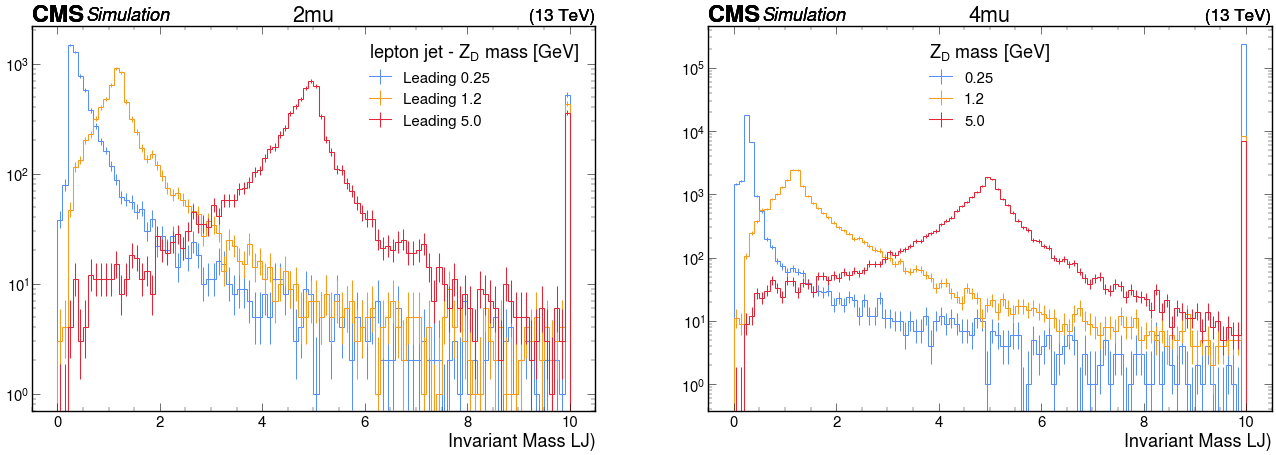

In [10]:
cha = ch1
npl = 2
mzd = ["0.25", "1.2", "5.0"]
htp = "ljm_invmass"
###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"][htp][cha, :], label = f"Leading {mzd[im]}")
    # utilities.plot(output[ss2]["hists"][htp][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"][htp][cha, :], label = mzd[im])
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

This is the reconstructed mass using the PF muon collection. The peaks here look nicer at their respective values but this does not use the LJ reconstruction algorithm. The $2\mu2e$ looks better because the two highest muon (in $p_T$) will make up the lepton-jet while for the $4\mu$ the two highest $p_T$ muons could be part of different lepton jets. This collection does not include dsa muon either but that could be a smaller effect. 

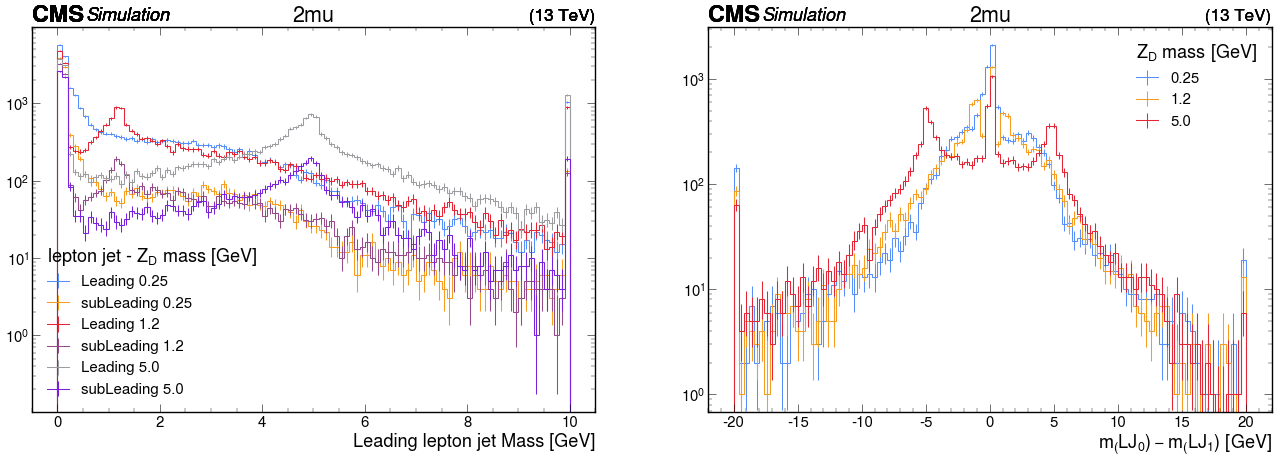

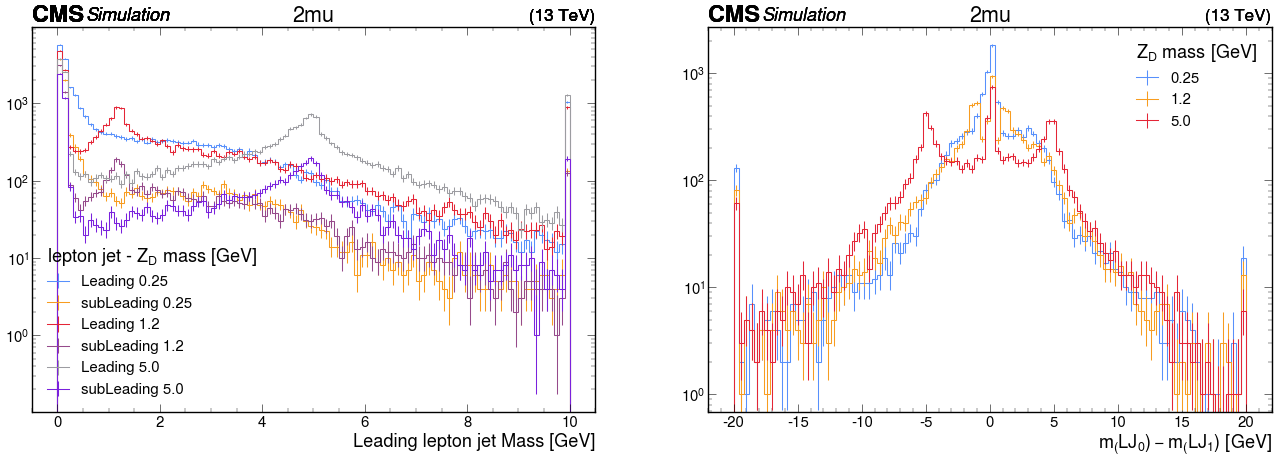

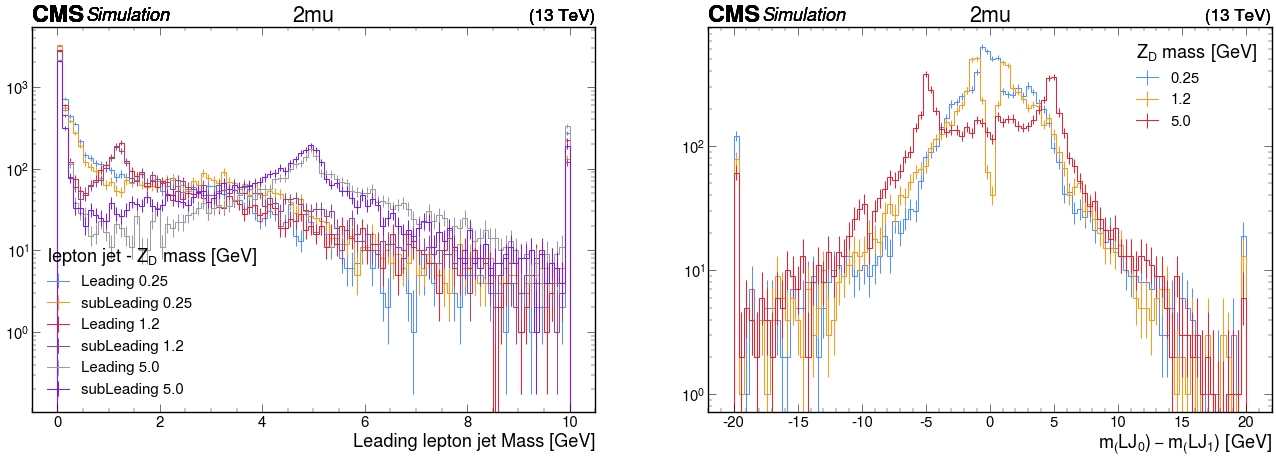

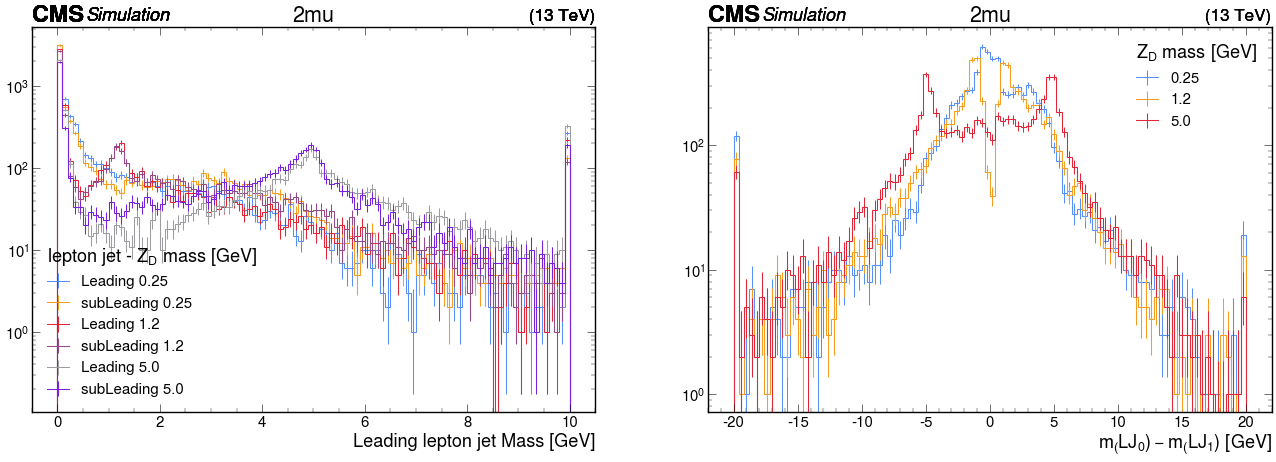

In [11]:
cha = [ch1, ch2, ch3, ch4]
npl = 2
mzd = ["0.25", "1.2", "5.0"]

###################
#### 2mu  ########
###################
for ch in cha:
    plt.subplots(1, npl, figsize=(npl*16, 10))
    plt.subplot(1,2,1)
    for im, ss2 in enumerate(sig2mu):
        utilities.plot(output[ss2]["hists"]["lj0_mass"][ch, :], label = f"Leading {mzd[im]}")
        utilities.plot(output[ss2]["hists"]["lj1_mass"][ch, :], label = f"subLeading {mzd[im]}")
    plt.title("2mu")
    plt.yscale("log")
    plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)
    
    plt.subplot(1,2,2)
    for im, ss2 in enumerate(sig2mu):
        utilities.plot(output[ss2]["hists"]["lj_mass_diff"][ch, :], label = mzd[im])
    plt.title("2mu")
    plt.yscale("log")
    plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

In [12]:
Now showing the different selection for each plot

SyntaxError: invalid syntax (4188271721.py, line 1)

In [ ]:
bkgovj